# ECMM447 CW2 Cross-layer Brokerage in Police Recorded Crime Networks

This notebook analyses UK Police Open Data as weighted area-crime-outcome networks for three England and Wales police forces: Metropolitan Police Service, West Midlands Police, and South Wales Police.

The research question is: **Which recorded crime categories act as cross-layer brokers between LSOA-level areas and recorded police outcomes, and how consistent are these brokerage roles across Metropolitan Police, West Midlands Police, and South Wales Police?**

The notebook uses street-level recorded crime data only. It does not use stop-and-search.it studies recorded association patterns, not causality, exact crime locations, or police effectiveness.

# SOHAIB KHALAF 760012524

## 1. Setup and Data Loading

The code uses relative paths. If the raw ZIP is already in `data/raw`, set `RUN_DOWNLOAD = False`. To ask data.police.uk to regenerate the custom six-month ZIP, set `RUN_DOWNLOAD = True`. The pipeline loads, cleans, audits, analyses, and regenerates the output tables and figures.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RUN_DOWNLOAD = False
FORCE_DOWNLOAD = False
MAX_WAIT_SECONDS = 1800

print(f"Project root: {PROJECT_ROOT.name}")

Project root: ECMM447 CW2


Imports are kept together here so the notebook can be run from top to bottom.

In [2]:
import pandas as pd

from src.config import FORCE_ORDER, FORCES, MONTHS, RAW_DIR, OUTPUTS_DIR, TABLES_DIR, FIGURES_DIR
from src.run_analysis import run_pipeline

In [3]:
outputs = run_pipeline(
    download=RUN_DOWNLOAD,
    force_download=FORCE_DOWNLOAD,
    max_wait_seconds=MAX_WAIT_SECONDS,
)
relative_outputs = {
    name: str(Path(path).relative_to(PROJECT_ROOT)) if path else None
    for name, path in outputs.items()
}
relative_outputs

{'zip_path': None,
 'processed_data': 'data\\processed\\processed_crime_outcomes.csv',
 'data_audit_csv': 'outputs\\data_audit.csv',
 'data_audit_md': 'outputs\\data_audit.md',
 'network_summary': 'outputs\\tables\\network_summary.csv',
 'top_crime_centrality': 'outputs\\tables\\top_crime_centrality.csv',
 'outcome_comparison': 'outputs\\tables\\outcome_comparison.csv',
 'brokerage_validation': 'outputs\\tables\\brokerage_validation.csv',
 'crime_similarity_edges': 'outputs\\tables\\crime_similarity_edges.csv',
 'crime_similarity_nodes': 'outputs\\tables\\crime_similarity_nodes.csv',
 'results_summary': 'outputs\\results_summary.md',
 'figure_1': 'outputs\\figures\\fig1_data_overview.png',
 'figure_2': 'outputs\\figures\\fig2_brokerage_comparison.png',
 'figure_3': 'outputs\\figures\\fig3_similarity_networks.png',
 'figure_4': 'outputs\\figures\\fig4_centrality_comparison.png',
 'figure_5': 'outputs\\figures\\figS1_outcome_heatmap.png'}

## 2. Data Audit

The audit checks records by force/month, missing values, unique category counts, local area fields, and whether crime/outcome labels are comparable across forces.

In [4]:
audit = pd.read_csv(OUTPUTS_DIR / "data_audit.csv")
audit.head(20)

,section,force,force_slug,month,field,category,count,percent,note
0,records,Metropolitan Police Service,metropolitan,all,records,total,540963,100.000,NaN
1,records_by_month,Metropolitan Police Service,metropolitan,2025-11,records,month,94209,17.415,NaN
2,records_by_month,Metropolitan Police Service,metropolitan,2025-12,records,month,90961,16.815,NaN
3,records_by_month,Metropolitan Police Service,metropolitan,2026-01,records,month,86692,16.025,NaN
4,records_by_month,Metropolitan Police Service,metropolitan,2026-02,records,month,84636,15.645,NaN
5,records_by_month,Metropolitan Police Service,metropolitan,2026-03,records,month,92801,17.155,NaN
6,records_by_month,Metropolitan Police Service,metropolitan,2026-04,records,month,91664,16.945,NaN
7,missing_values,Metropolitan Police Service,metropolitan,all,crime_id,missing,105626,19.526,NaN
8,missing_values,Metropolitan Police Service,metropolitan,all,crime_type,missing,0,0.000,NaN
9,missing_values,Metropolitan Police Service,metropolitan,all,outcome_category,missing,105626,19.526,NaN


In [5]:
audit[audit["section"].isin(["records", "missing_values", "unique_counts"])].head(40)

,section,force,force_slug,month,field,category,count,percent,note
0,records,Metropolitan Police Service,metropolitan,all,records,total,540963,100.000,NaN
7,missing_values,Metropolitan Police Service,metropolitan,all,crime_id,missing,105626,19.526,NaN
8,missing_values,Metropolitan Police Service,metropolitan,all,crime_type,missing,0,0.000,NaN
9,missing_values,Metropolitan Police Service,metropolitan,all,outcome_category,missing,105626,19.526,NaN
10,missing_values,Metropolitan Police Service,metropolitan,all,lsoa_code,missing,0,0.000,NaN
11,missing_values,Metropolitan Police Service,metropolitan,all,lsoa_name,missing,0,0.000,NaN
12,missing_values,Metropolitan Police Service,metropolitan,all,month,missing,0,0.000,NaN
13,unique_counts,Metropolitan Police Service,metropolitan,all,crime_type,unique_crime_types,14,NaN,NaN
14,unique_counts,Metropolitan Police Service,metropolitan,all,outcome_category,unique_outcomes,13,NaN,NaN
15,unique_counts,Metropolitan Police Service,metropolitan,all,lsoa_code,unique_lsoas,7115,NaN,NaN


## 3. Network Construction

The project builds three graphs for each force: an area-crime bipartite graph, a crime-outcome bipartite graph, and a combined typed multilayer graph where crime type is the shared mediator node. The combined structure is implemented as one NetworkX graph for centrality calculation, but the analytical framing keeps area, crime, and outcome nodes as distinct node types.

In [6]:
network_summary = pd.read_csv(TABLES_DIR / "network_summary.csv")
network_summary

,force,force_slug,layer,records,records_with_lsoa,records_with_outcome,areas,crime_types,outcomes,nodes,edges,density,total_edge_weight,average_weighted_degree
0,Metropolitan Police Service,metropolitan,area_crime,540963,540963,435337,7115,14,13,7129,56195,0.564150,540963.0,151.764062
1,Metropolitan Police Service,metropolitan,crime_outcome,540963,540963,435337,7115,14,13,26,148,0.875740,435337.0,33487.461538
2,Metropolitan Police Service,metropolitan,combined,540963,540963,435337,7115,14,13,7142,56343,0.002209,976300.0,273.396808
3,West Midlands Police,west-midlands,area_crime,152098,152098,147116,1750,14,12,1764,17281,0.705347,152098.0,172.446712
4,West Midlands Police,west-midlands,crime_outcome,152098,152098,147116,1750,14,12,25,117,0.750000,147116.0,11769.280000
5,West Midlands Police,west-midlands,combined,152098,152098,147116,1750,14,12,1776,17398,0.011038,299214.0,336.952703
6,South Wales Police,south-wales,area_crime,59031,57666,52617,927,14,11,941,7573,0.583526,57666.0,122.563231
7,South Wales Police,south-wales,crime_outcome,59031,57666,52617,927,14,11,24,112,0.783217,52617.0,4384.750000
8,South Wales Police,south-wales,combined,59031,57666,52617,927,14,11,952,7685,0.016977,110283.0,231.686975


## 4. Cross-layer Brokerage Score

The main result is no longer a simple PageRank or volume ranking. The brokerage score combines area spread, outcome connectivity, outcome entropy and weighted-distance betweenness. Anti-social behaviour is excluded from this score because it has no crime-outcome edges in the selected street-level data.

In [7]:
centrality = pd.read_csv(TABLES_DIR / "top_crime_centrality.csv")
centrality[centrality["brokerage_eligible"]].sort_values(
    ["force_slug", "brokerage_rank"]
).groupby("force_slug").head(6)[
    [
        "force",
        "crime_type",
        "brokerage_rank",
        "brokerage_score",
        "area_spread",
        "outcome_connectivity",
        "outcome_entropy_norm",
        "betweenness",
        "area_crime_strength",
    ]
]

,force,crime_type,brokerage_rank,brokerage_score,area_spread,outcome_connectivity,outcome_entropy_norm,betweenness,area_crime_strength
0,Metropolitan Police Service,Violence and sexual offences,1.0,0.923077,0.904568,1.000000,0.536663,0.866710,133975.0
1,Metropolitan Police Service,Drugs,2.0,0.663462,0.606887,0.923077,0.650349,0.021873,24684.0
2,Metropolitan Police Service,Other crime,3.0,0.644231,0.424736,0.923077,0.684366,0.030918,6526.0
3,Metropolitan Police Service,Other theft,3.0,0.644231,0.707238,0.923077,0.313836,0.070984,47532.0
4,Metropolitan Police Service,Public order,5.0,0.625000,0.636683,0.923077,0.555332,0.011886,27934.0
5,Metropolitan Police Service,Vehicle crime,5.0,0.625000,0.714968,0.923077,0.200383,0.087859,39770.0
14,South Wales Police,Violence and sexual offences,1.0,0.855769,0.959008,0.909091,0.580263,0.985564,22644.0
15,South Wales Police,Drugs,2.0,0.740385,0.593312,0.909091,0.713434,0.037362,1821.0
16,South Wales Police,Public order,2.0,0.740385,0.855448,0.909091,0.574913,0.011266,6087.0
17,South Wales Police,Shoplifting,4.0,0.711538,0.402373,1.000000,0.556772,0.075648,5554.0


## 5. Descriptive Validation (Spearman Checks)

### Descriptive Validation

Two Spearman rank correlation checks are used to evaluate whether the brokerage score simply reproduces crime volume, and whether broker roles are consistent across forces.

With approximately 13 brokerage-eligible crime categories per force, these are descriptive checks rather than formal hypothesis tests. The table is generated by `compute_brokerage_validation` in the pipeline and saved as `outputs/tables/brokerage_validation.csv`.

In [8]:
# Load and display Spearman validation results
validation = pd.read_csv(TABLES_DIR / "brokerage_validation.csv")
print("=== Brokerage Validation ===")
print(validation.to_string(index=False))

=== Brokerage Validation ===
                       check_type       force_1       force_2  n_crime_types  spearman_rho
              brokerage_vs_volume  metropolitan           NaN             13      0.570250
              brokerage_vs_volume   south-wales           NaN             13      0.853998
              brokerage_vs_volume west-midlands           NaN             13      0.581269
cross_force_brokerage_consistency  metropolitan   south-wales             13      0.845304
cross_force_brokerage_consistency  metropolitan west-midlands             13      0.779006
cross_force_brokerage_consistency   south-wales west-midlands             13      0.881215


## 6. Crime-type Outcome-profile Similarity Network

The similarity network is a pruned one-mode projection from crime types' recorded outcome profiles. Edges use cosine similarity between outcome-proportion vectors and the top-3 edge rule is a descriptive pruning step rather than a statistical threshold.

In [9]:
similarity_nodes = pd.read_csv(TABLES_DIR / "crime_similarity_nodes.csv")
similarity_edges = pd.read_csv(TABLES_DIR / "crime_similarity_edges.csv")
print("Similarity nodes:")
print(similarity_nodes.head(10).to_string(index=False))
print("\nSimilarity edges:")
print(similarity_edges.head(10).to_string(index=False))

Similarity nodes:
                      force   force_slug                crime_type  community_id  similarity_degree  similarity_strength                                                        method
Metropolitan Police Service metropolitan             Bicycle theft             1                  4             3.980614 cosine_outcome_profile_top_3_edges_per_node_greedy_modularity
Metropolitan Police Service metropolitan                  Burglary             1                  6             5.881108 cosine_outcome_profile_top_3_edges_per_node_greedy_modularity
Metropolitan Police Service metropolitan Criminal damage and arson             1                  3             2.925775 cosine_outcome_profile_top_3_edges_per_node_greedy_modularity
Metropolitan Police Service metropolitan                     Drugs             2                  3             2.465149 cosine_outcome_profile_top_3_edges_per_node_greedy_modularity
Metropolitan Police Service metropolitan               Other crime 

## 7. Figures

Figures 1-4 are all included in the report. Fig. 4 (centrality-metric comparison and rank-size distribution) is the appendix figure. Fig. S1 (outcome heatmap) is supplementary and not included in the report.

fig1_data_overview.png


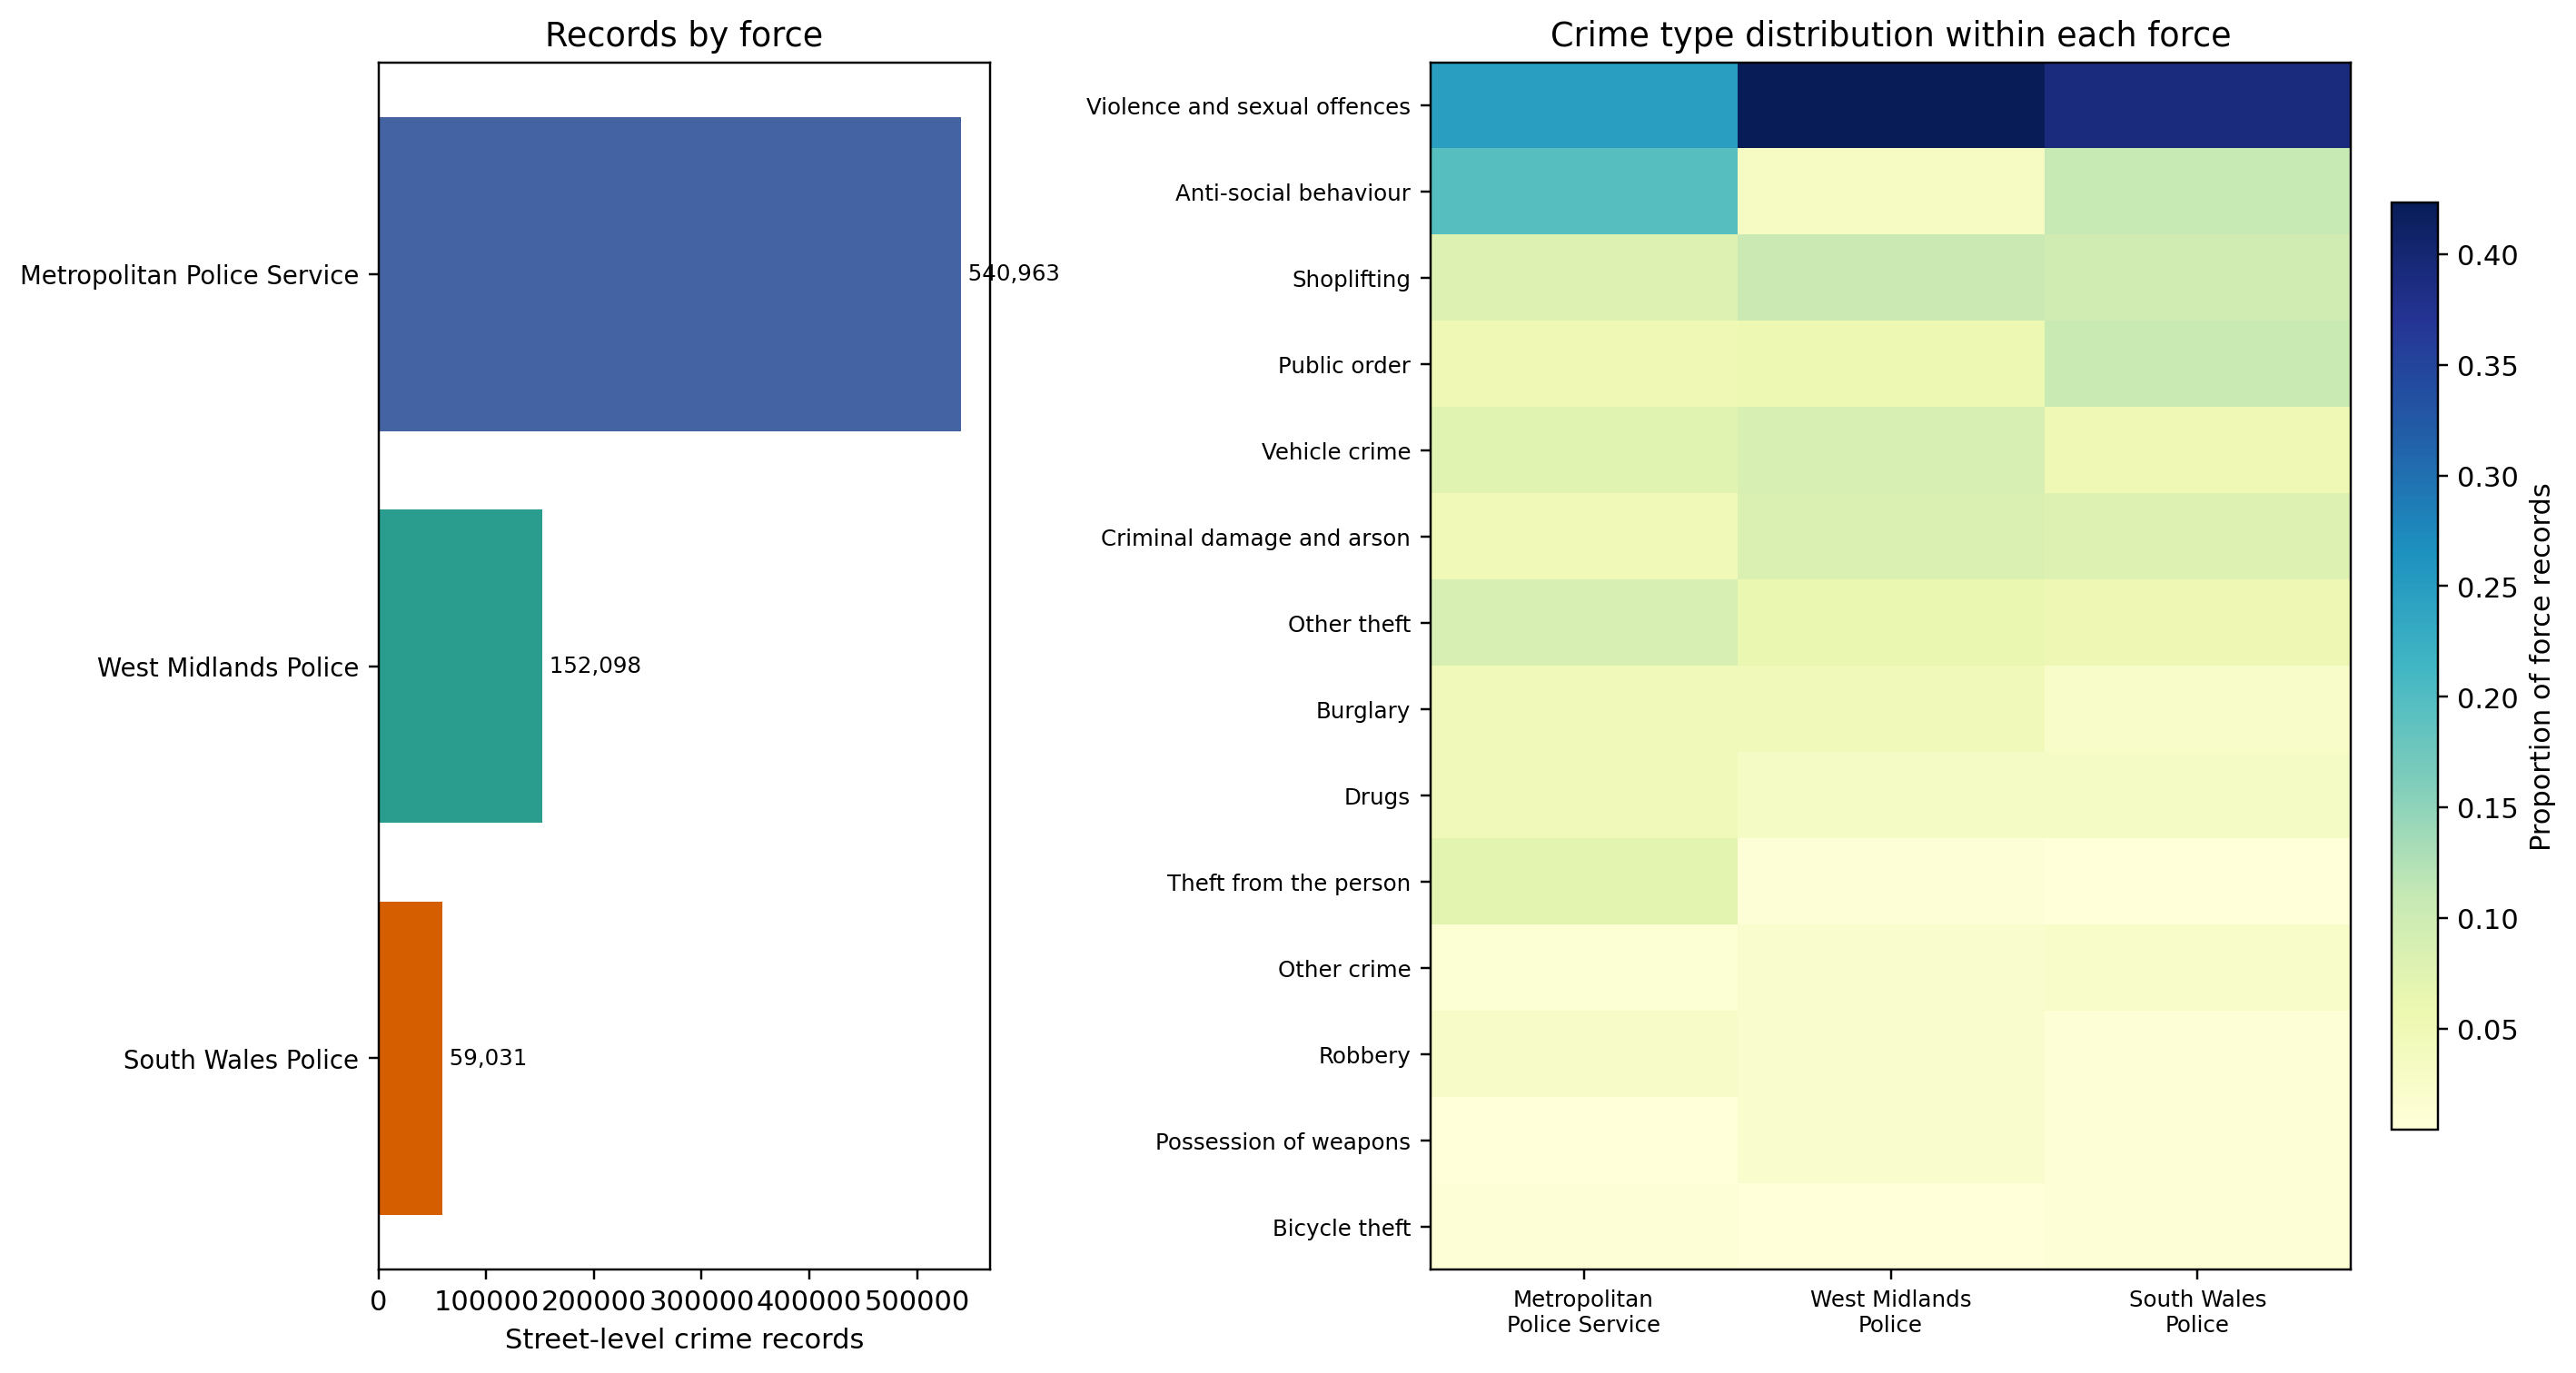

fig2_brokerage_comparison.png


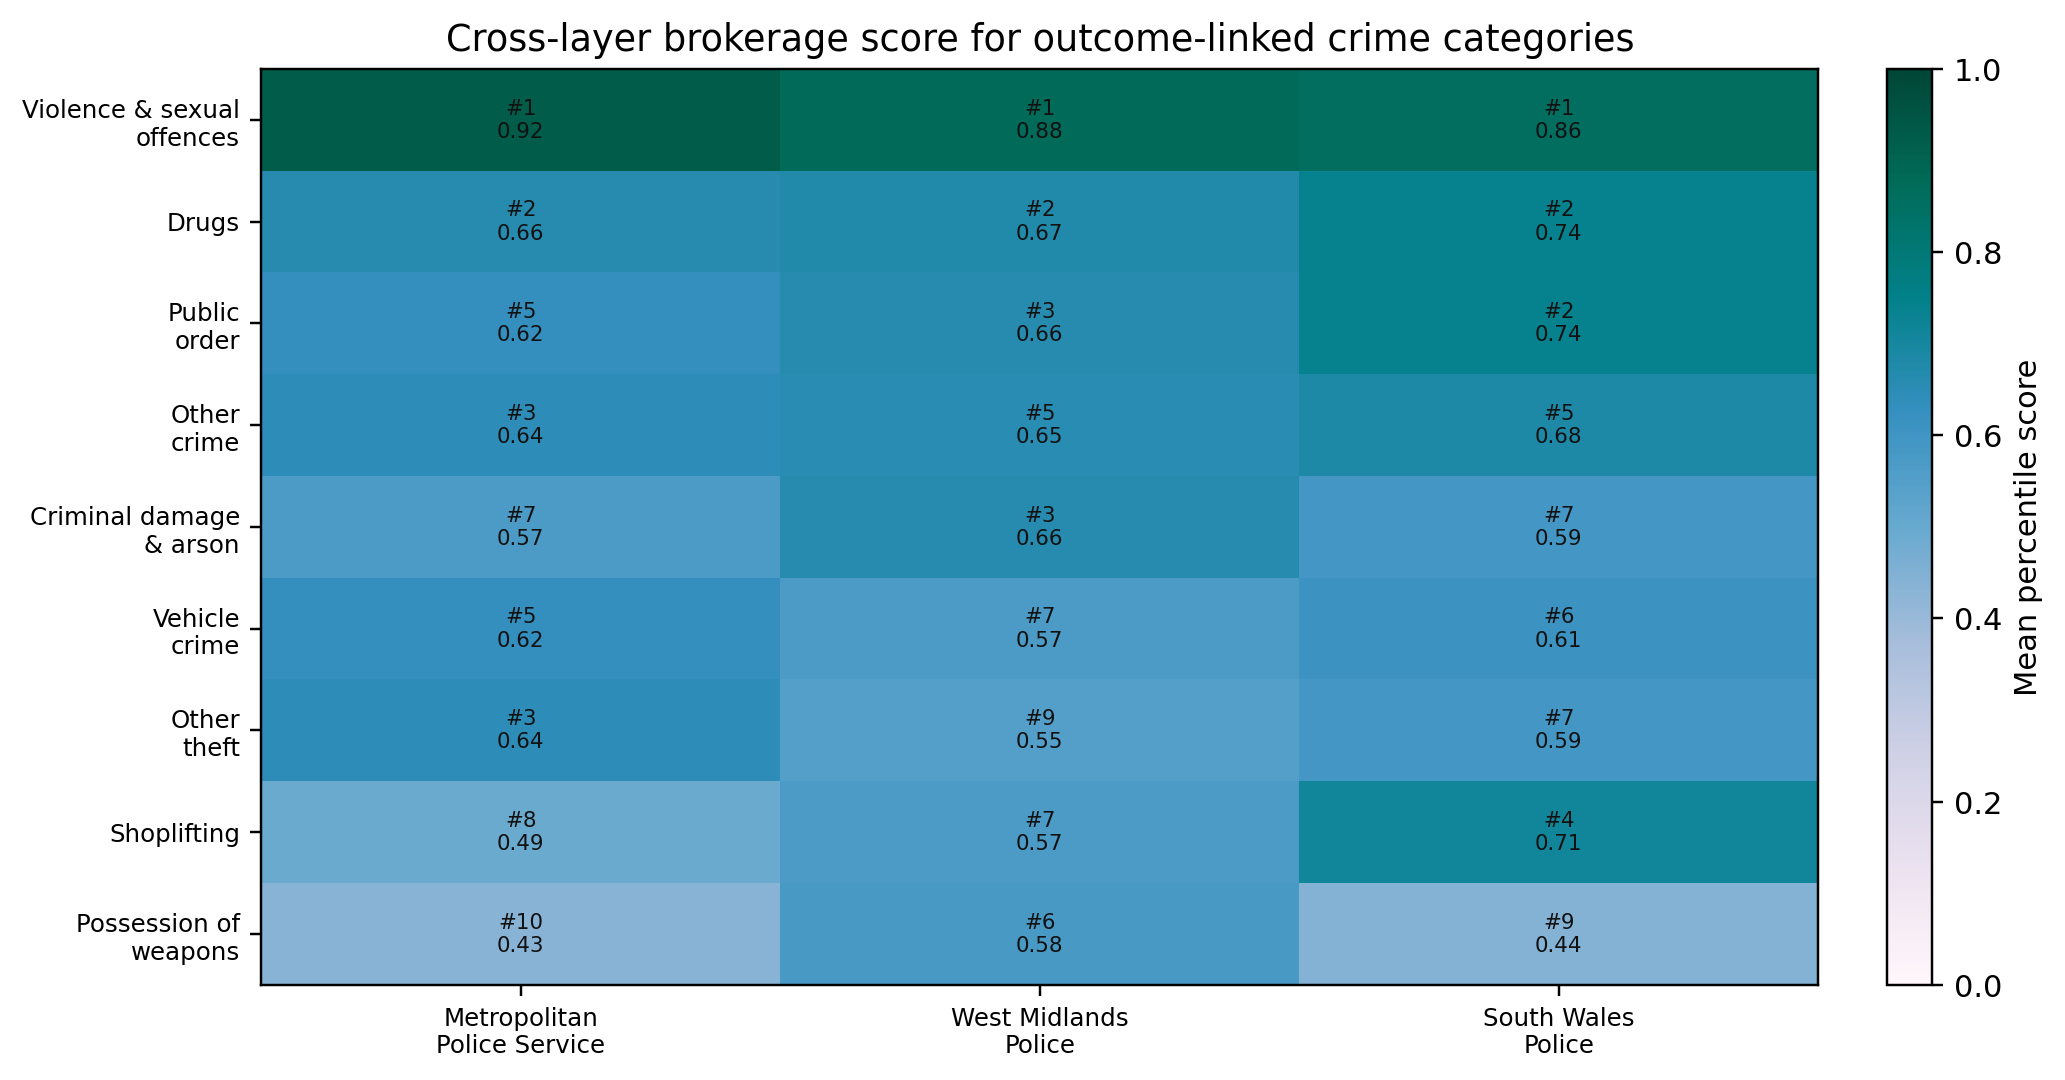

fig3_similarity_networks.png


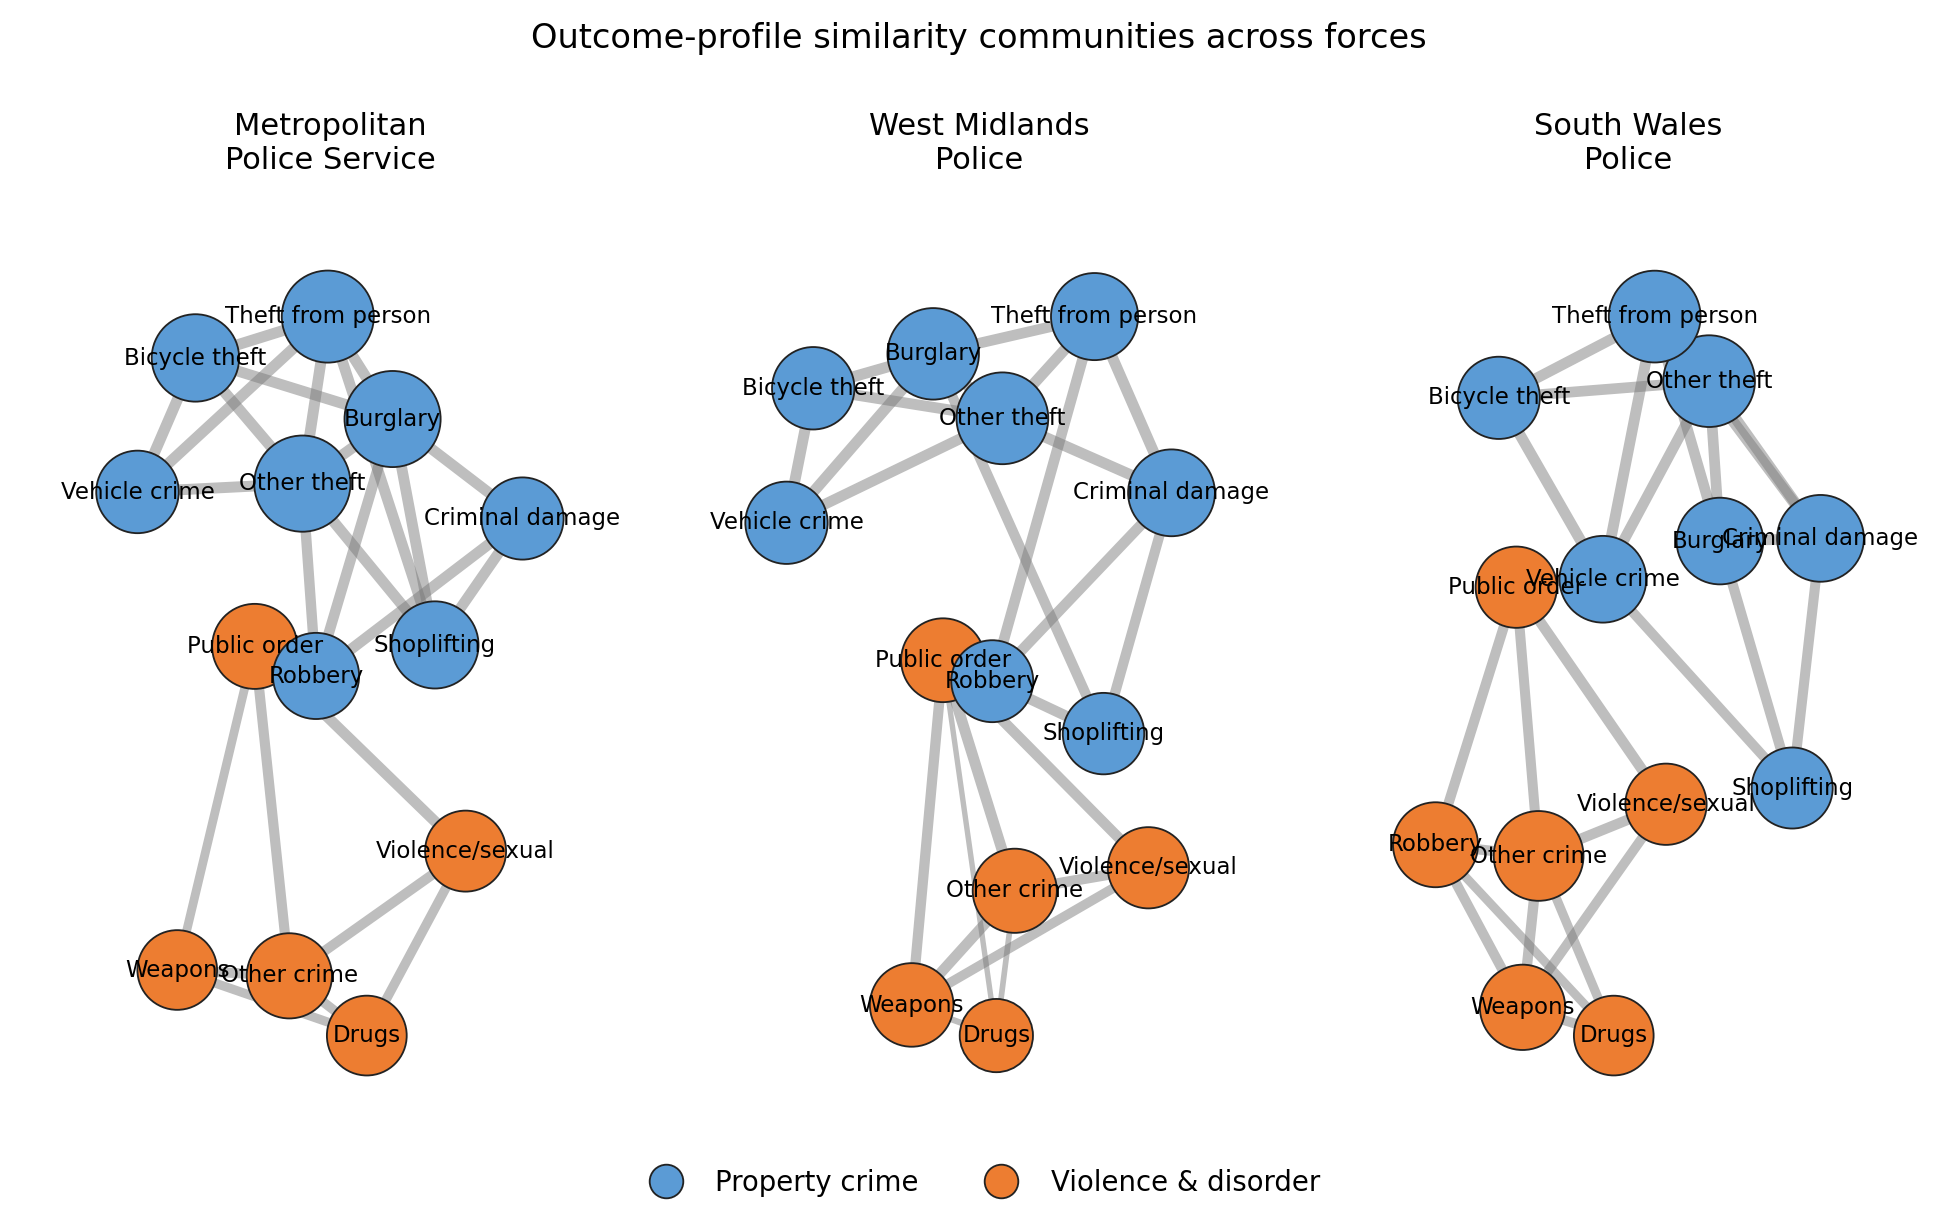

fig4_centrality_comparison.png


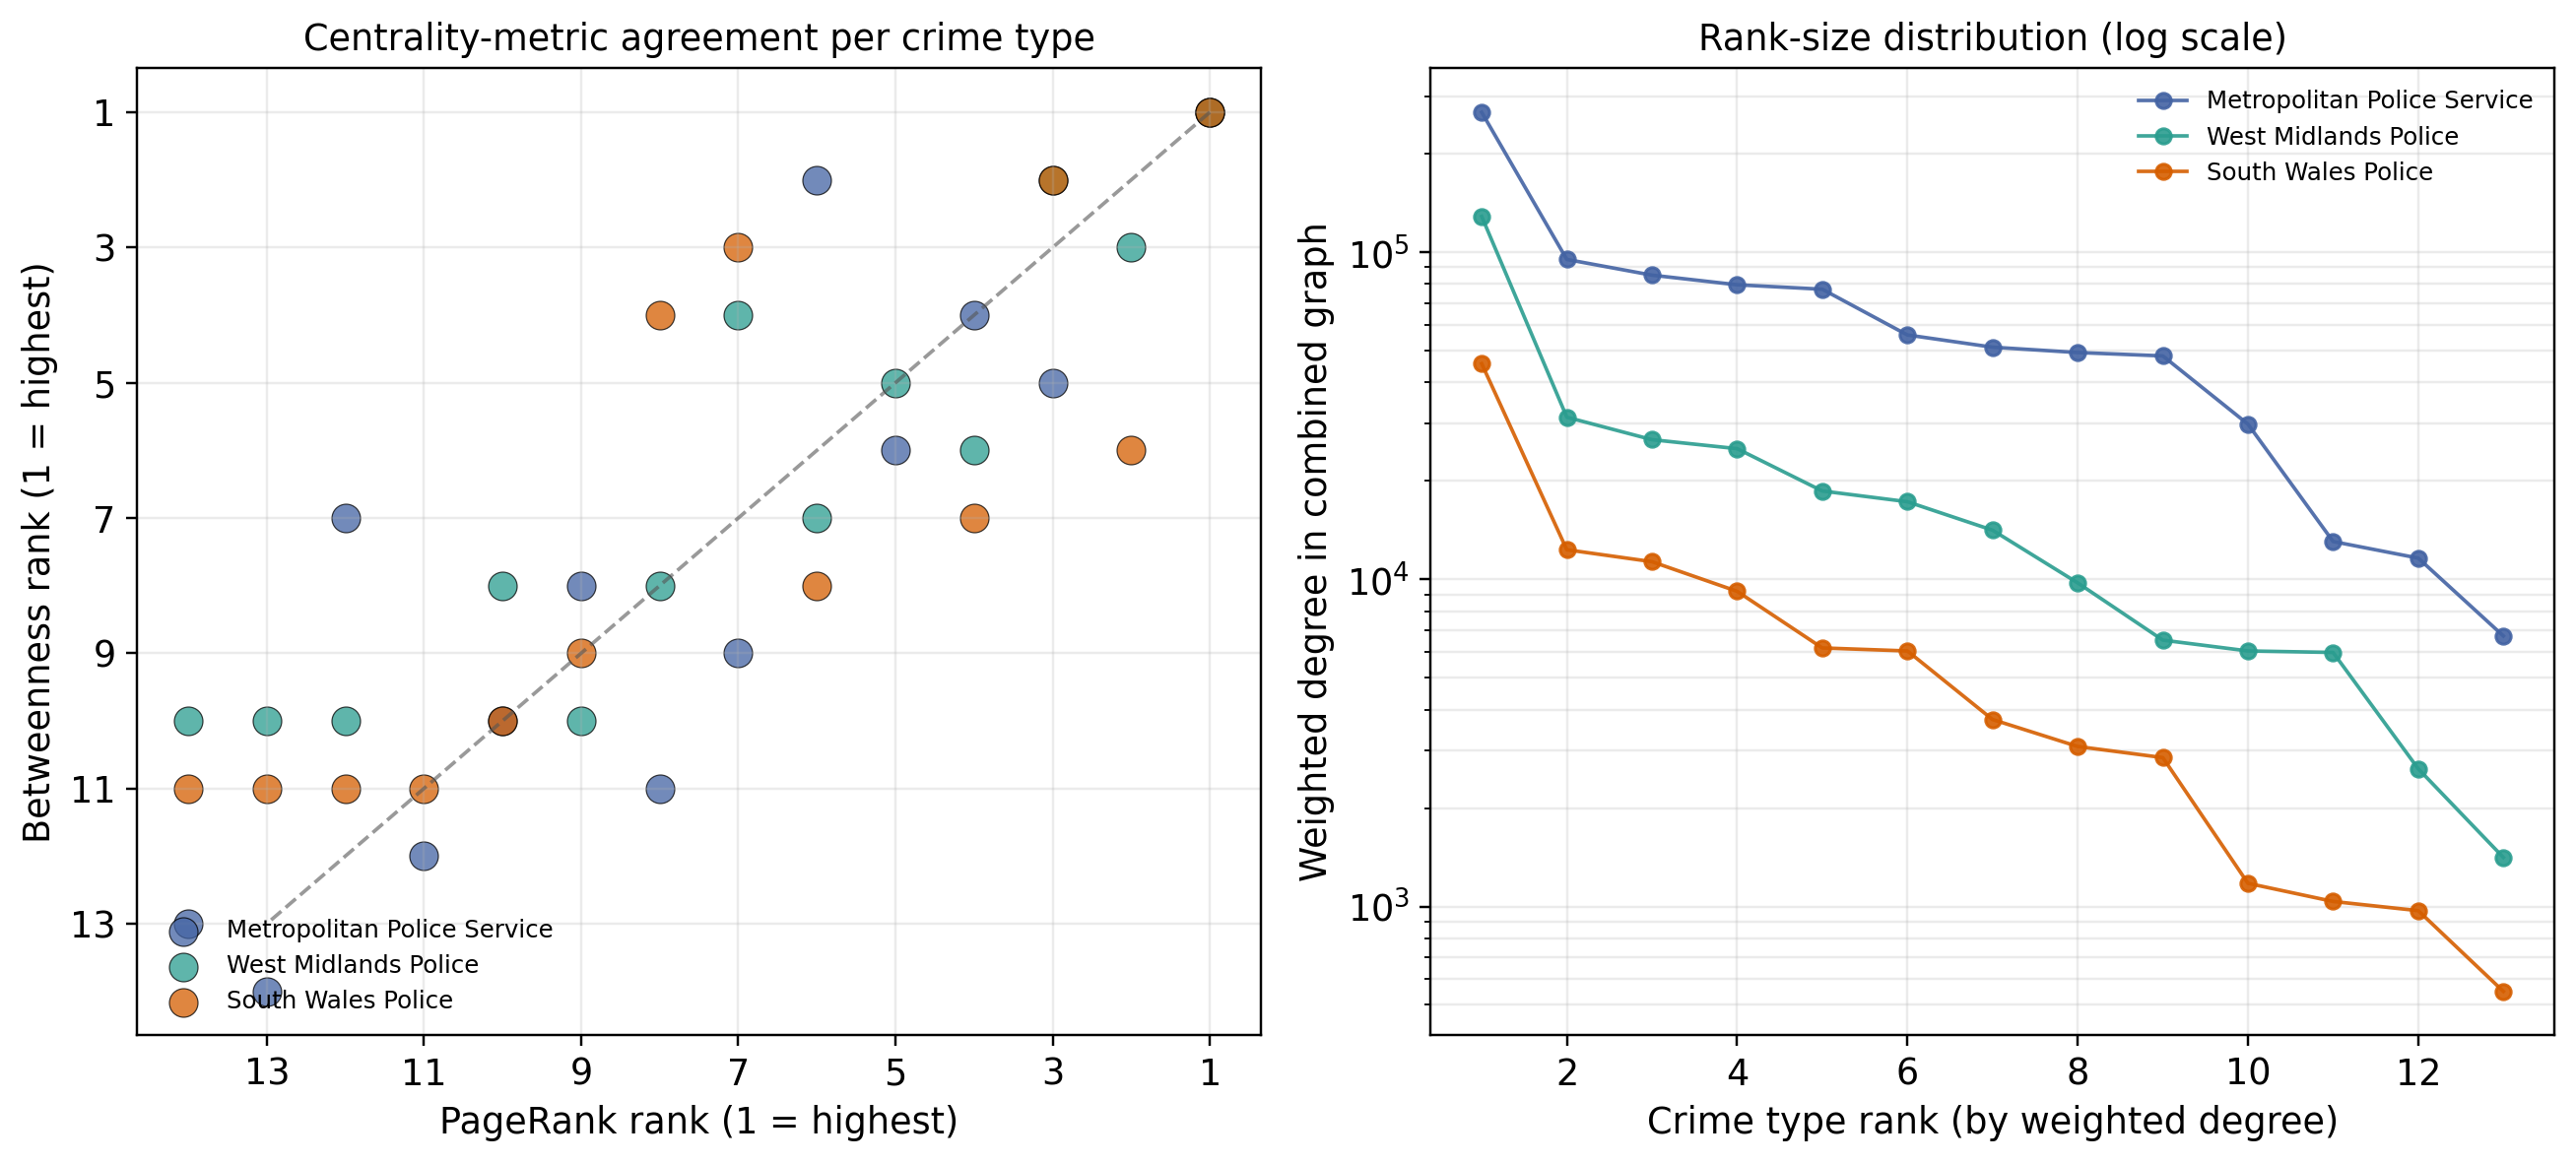

In [10]:
from IPython.display import Image, display

for fig_name in [
    "fig1_data_overview.png",
    "fig2_brokerage_comparison.png",
    "fig3_similarity_networks.png",
    "fig4_centrality_comparison.png",
]:
    fig = FIGURES_DIR / fig_name
    print(fig.name)
    display(Image(filename=str(fig)))


## 8. Results Summary

Violence and sexual offences is the strongest cross-layer broker in all three forces. Drugs is the more interesting second result: it ranks second by brokerage in every force even though it is not simply the highest-volume category, because it has broad area spread, high outcome connectivity, and high outcome entropy.

The crime-type outcome-profile similarity networks give a second, complementary view of the data. They show a broadly stable property-crime community and a violence/disorder community across the three forces. Drugs sits in the more diverse outcome-profile community, which supports the entropy part of the brokerage result.

These are descriptive patterns in recorded open police data, not causal claims about actual crime, exact locations, or police effectiveness.
